# Predição de Gênero - Análise de Reviews

- **Aluno:** Pedro Yutaro Mont Morency Nakamura  
- **Data:** 17/05/2026
- **Objetivo:** Implementar e otimizar a abordagem de representação textual baseada em frequência (espaço esparso de alta dimensionalidade). É aqui que reside o modelo campeão do projeto.

# FASE-1

Este notebook compreende a implementação da **Fase 1** do projeto de predição de gênero com base em revisões de e-commerce. 
Aqui, aplicamos técnicas de extração de características textuais baseadas em frequência (N-gramas de palavras e caracteres), integradas a metadados estruturais, estilométricos e demográficos através de um pipeline robusto do Scikit-Learn.

# 0. Configurações e Importações de Dependẽncias e Dados

In [100]:
import os
import time
import pickle
import pandas as pd
import numpy as np

# Visualização de Dados
import matplotlib.pyplot as plt
import seaborn as sns

# Pré-Processamento
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
import spacy
from tqdm import tqdm
from spacy.matcher import Matcher

# Estruturas e estatística
from scipy.stats import loguniform, randint, uniform, mannwhitneyu

# Classificadores e seleção
from xgboost import XGBClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import HistGradientBoostingClassifier

# Validação e busca de hiperparâmetros
from sklearn.base import clone, BaseEstimator, TransformerMixin
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve
from sklearn.pipeline import Pipeline, FeatureUnion

## 0.1 Configuração de Gráficos

In [2]:
# Configurações de exibição do Pandas
pd.set_option('display.max_columns', None)

In [3]:
# Configurações de visualização
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

## 0.2 Carregamento do modelo SpaCy para Português

In [4]:
try:
    # Carrega apenas componentes necessarios para POS/lemmas.
    disable=["parser", "ner"]
    nlp = spacy.load("pt_core_news_lg", disable=disable)
    print("✅ SpaCy pt_core_news_lg carregado com sucesso!")
except Exception as e:
    print(f"❌ Erro ao carregar o modelo: {e}")

✅ SpaCy pt_core_news_lg carregado com sucesso!


## 0.3 Importação dos Datasets

In [5]:
# Caminhos para os dados
TRAIN_PATH = '../data/treino.csv'
VALIDATION_PATH = '../data/validacao.csv'

print("Carregando os datasets brutos...")
try:
    df_train_raw = pd.read_csv(TRAIN_PATH, encoding='utf-8', low_memory=False)
    df_val_raw = pd.read_csv(VALIDATION_PATH, encoding='utf-8', low_memory=False)
    print(f"Dataset de Treino carregado: {df_train_raw.shape[0]} linhas e {df_train_raw.shape[1]} colunas.")
    print(f"Dataset de Validação carregado: {df_val_raw.shape[0]} linhas and {df_val_raw.shape[1]} colunas.")
except FileNotFoundError as e:
    print(f"Erro: Certifique-se de que os arquivos 'treino.csv' e 'validacao.csv' estão no mesmo diretório. {e}")

Carregando os datasets brutos...
Dataset de Treino carregado: 76942 linhas e 14 colunas.
Dataset de Validação carregado: 25647 linhas and 14 colunas.


# 1. Tratamento Essencial e Engenharia de Atributos Inicial

Para garantir a consistência com a Análise Exploratória de Dados (EDA):
1. Unificamos as colunas de texto `review_title` e `review_text` em uma única feature chamada `full_text`.
2. Removemos registros cujo texto combinado resultou em strings vazias ou nulas, pois dados sem conteúdo textual não possuem sinal preditivo para NLP.
3. Isolamos as variáveis preditoras ($X$) do vetor de alvos binários ($y$).

In [6]:
def pre_process_pipeline(df):
    """
    Realiza o tratamento estrutural obrigatório: fusão de textos,
    limpeza de NaNs nas strings e descarte de linhas semanticamente vazias.
    """
    df_processed = df.copy()
    
    # Substitui nulos por strings vazias para evitar concatenação com NaN (que resultaria em NaN)
    df_processed['review_title'] = df_processed['review_title'].fillna("")
    df_processed['review_text'] = df_processed['review_text'].fillna("")
    
    # Criação da feature unificada validada na EDA
    df_processed['full_text'] = df_processed['review_title'] + " " + df_processed['review_text']
    df_processed['full_text'] = df_processed['full_text'].str.strip()
    
    # Remove as linhas onde o full_text ficou completamente sem conteúdo
    df_processed = df_processed[df_processed['full_text'].str.len() > 0]
    
    return df_processed

Executando o tratamento em ambos os conjuntos de forma isolada:

In [7]:
df_train = pre_process_pipeline(df_train_raw)
df_val = pre_process_pipeline(df_val_raw)
print("Aplicando tratamento estrutural Aplicado")

Aplicando tratamento estrutural Aplicado


Definição exata das colunas preditoras que serão consumidas pelo ColumnTransformer

In [8]:
features = ['full_text', 'reviewer_birth_year', 'site_category_lv1', 'site_category_lv2']
target = 'reviewer_gender'

Separação definitiva de features e targets

In [9]:
X_train = df_train[features].copy()
y_train = df_train[target].copy()

X_val = df_val[features].copy()
y_val = df_val[target].copy()

print("\n--- Estrutura Final das Matrizes para Modelagem ---")
print(f"X_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape} | y_val:   {y_val.shape}")
print(f"Distribuição do Alvo no Treino:\n{y_train.value_counts(normalize=True).round(4) * 100}")


--- Estrutura Final das Matrizes para Modelagem ---
X_train: (76899, 4) | y_train: (76899,)
X_val:   (25635, 4) | y_val:   (25635,)
Distribuição do Alvo no Treino:
reviewer_gender
M    51.59
F    48.41
Name: proportion, dtype: float64


# 2. Configuração Lexical e Transformadores Customizados

Apesar do TF-IDF lidar bem com as frequências das palavras, a remoção de *stop words* tradicionais ajuda a reduzir a esparsidade e o ruído da matriz. 

No entanto, com base nas análises exploratórias, **pronomes de posse e pronomes pessoais** carregam forte viés de gênero no português (ex: "meu" vs "minha").

Portanto, será criada uma lista de *stop words* customizada que preserva essas flexões.

## 2.1 Importando e Configurando Stop Words:

In [98]:
# Download de stopwords (certifique-se de que o ambiente uv tem o nltk instalado)
nltk.download('stopwords', quiet=True)
# Criação da lista de Stop Words Customizada
stop_words_pt = stopwords.words('portuguese')

pronomes_genero = ['meu', 'minha', 'meus', 'minhas', 'teu', 'tua', 'teus', 'tuas', 'ele', 'ela', 'eles', 'elas', 'nosso', 'nossa', 'nossos', 'nossas']

domain_stop_words = ['produto', 'recomendo', 'entrega', 'excelente', 'ótimo', 'qualidade', 'recebi', 'comprei', 'americanas', 'ainda', 'compra', 'pra', 'dia', 'nao', 'pois', 'comprar', 'expectativas', 'dias', 'celular', 'tudo']

stop_words_custom = [word for word in stop_words_pt if word not in pronomes_genero]
stop_words_final = stop_words_custom + domain_stop_words

print(f"Lista de Stop Words customizada criada com {len(stop_words_final)} palavras (pronomes de gênero preservados).")

Lista de Stop Words customizada criada com 211 palavras (pronomes de gênero preservados).


# 3. Pré-Processamento - Definição de Classes Transformadoras

Como será necessário orquestrar simultâneamente:
- O texto puro
- A extração de classes gramaticais (POS)
- A estilometria
- Os metadados categóricos de forma

A melhor abordagem é construir Transformadores Customizados que se integram nativamente ao ecossistema do Scikit-Learn

### Plano de Estruturação do Pipeline:
O pipeline será dividido em 3 branches que processam diferentes aspectos do dado bruto em paralelo, unindo os resultados no final para alimentar o classificador:

- B1: **Processamento de Texto (NLP Semântico)**: Limpa o texto preservando flexões de gênero (sem stemming), injeta tokens de estilometria (__multipunct__) e aplica o TfidfVectorizer (N-gramas 1 e 2).

- B2: **Engenharia de Features (Sintaxe e Estilometria)**: Extrai e calcula as proporções de Caixa Alta (Q6.1), repetições (Q6) e as classes gramaticais via spaCy (Q10). Preenche nulos e normaliza a escala (StandardScaler).

- B3: **Metadados Estruturados**: Preenche valores nulos (mediana para idade, "Desconhecido" para categoria), normaliza a idade e aplica OneHotEncoder na categoria.

## 3.1. Implementação dos Transformadores Customizados

Aqui recriamos as classes que higienizam o texto e extraem a estilometria, garantindo que o TF-IDF receba o texto limpo, mas com a pontuação expressiva mapeada (Q6).

#### A. TextCleaner
Higieniza o texto para o TF-IDF, transformando pontuações expressivas em tokens textuais contáveis, preservando as conclusões do Q6.

In [63]:
class TextCleaner(BaseEstimator, TransformerMixin):
    """
    Higieniza o texto para o TF-IDF:
    1. Remove ruídos de internet (URLs, Menções).
    2. Transforma pontuações expressivas em tokens (Q6).
    3. Remove números e pontuações isoladas para otimizar o TF-IDF de caracteres.
    """    
    def fit(self, X, y=None):
        return self
        
    def transform(self, X, y=None):
        cleaned_texts = []
        texts = X.fillna("").astype(str).tolist()
        
        for text in texts:
            t = text.lower()
            
            # 1. REMOÇÃO DE RUÍDOS WEB
            t = re.sub(r'http\S+|www\.\S+', ' ', t)
            t = re.sub(r'@\w+', ' ', t)

            # 2. PRESERVAÇÃO DE ESTILOMETRIA (Q6)
            t = re.sub(r'[!?\.]{2,}', ' __multipunct__ ', t)
            t = re.sub(r'([a-z])\1{2,}', r'\1 __repeatletter__ ', t)

            # 3. LIMPEZA FINAL (Sua adição crucial)
            # Mantém apenas letras, espaços e o '_' (para proteger nossos tokens customizados)
            t = re.sub(r'[^a-zãõáéíóúâêîôûàèìòùç\s_]', ' ', t)
            
            # Remove espaços múltiplos
            t = re.sub(r'\s+', ' ', t).strip()
            cleaned_texts.append(t)
            
        return cleaned_texts

#### B. FeatureExtractor
Extrai as proporções estruturais do texto em uma matriz densa: Uso de Caixa Alta (Q6) e POS Tagging (Q10).

In [64]:
class FeatureExtractor(BaseEstimator, TransformerMixin):
    """
    Transformador Denso: Extrai estatísticas morfossintáticas (Q10), 
    estilométricas (Q6) e estruturais (Q4) diretamente do texto bruto.
    """
    def fit(self, X, y=None):
        return self
        
    def transform(self, X, y=None):
        features = []
        texts = X.fillna("").astype(str).tolist()
        
        # nlp.pipe garante processamento ultrarrápido
        for doc in nlp.pipe(texts, batch_size=500):
            text_str = doc.text
            total_tokens = len(doc) + 1
            
            # 1. Contagens do spaCy (Q10)
            counts = {'NOUN': 0, 'ADJ': 0, 'VERB': 0, 'PROPN': 0}
            for token in doc:
                if token.pos_ in counts:
                    counts[token.pos_] += 1
            
            # 2. Estilometria Numérica (Q6)
            upper_count = len(re.findall(r'\b[A-ZÀ-Ú]{2,}\b', text_str))
            multipunct_count = len(re.findall(r'[!?\.]{2,}', text_str))
            
            # Constrói o dicionário de features contínuas
            features.append({
                'noun_ratio': counts['NOUN'] / total_tokens,
                'adj_ratio': counts['ADJ'] / total_tokens,
                'verb_ratio': counts['VERB'] / total_tokens,
                'propn_ratio': counts['PROPN'] / total_tokens,
                'upper_ratio': upper_count / total_tokens,
                'multipunct_ratio': multipunct_count / total_tokens
            })
            
        return pd.DataFrame(features)

# 4. Montagem do Pipeline Principal
**Fase 1: Otimização Extrema do TF-IDF**

Conectando os transformadores em um único objeto de pré-processamento. Este será usado para o treino e validação em cima dos dados brutos.

- **N-gramas de Palavras vs. N-gramas de Caracteres**
- **Ajuste do max_features e min_df**

#### Objetivo: extrair o máximo de sinal possível do texto usando o TfidfVectorizer.

Na Q9, é observado que a flexão do adjetivo/verbo (o final da palavra) é o maior indicador de gênero em português, usar apenas N-gramas de palavras pode ser limitante se o usuário digitar algo fora do vocabulário comum (ex: "maravilhooooosa" ou "lindaaaaa").

Para resolver isso, a estratégia a ser adotada será combinar:
- A. Word N-grams (para capturar contexto, como "produto bom") com;
- B. Character N-grams (para capturar a morfologia e sufixos de gênero, como "ada", "issima", "inho").

## 4.1 Definição das Branches

**Passo 1: Definindo a B1 com FeatureUnion**

O Scikit-Learn permite unir múltiplas estratégias de vetorização usando o FeatureUnion.

### Branch 1: Texto Otimizado para Matriz Esparsa (Word + Character N-grams)
Representação Textual Baseada em Frequência (Espaço Esparso)

In [88]:
text_pipeline = Pipeline([
    ('cleaner', TextCleaner()),
    ('vectorizer', FeatureUnion([
        # Estratégia A: Captura o contexto e bigramas comuns ("muito satisfeito")
        ('word_tfidf', TfidfVectorizer(
            analyzer='word',
            ngram_range=(1, 2),
            stop_words=stop_words_final,
            min_df=5,
            max_features=10_000 # Expandimos de 10k para 15k para cobrir mais vocabulário
        )),
        
        # Estratégia B: Captura sufixos de gênero e variações de digitação
        # ngram_range=(3, 5) extrai pedaços de 3 a 5 letras. Ex: "linda" -> "lin", "ind", "nda".
        ('char_tfidf', TfidfVectorizer(
            analyzer='char',
            ngram_range=(3, 5),
            min_df=10,
            max_features=15_000 # Limite para não estourar a memória RAM,
        ))
    ]))
])

### Branch 2: Features Numéricas Extraídas (POS e Estilometria)

Características Morfossintáticas e Estilométricas Densas (NLP):
- Extrai NOUN, ADJ, VERB, PROPN, Upper, Multipunct, Repeatchar e Word_count
- Normaliza as proporções contínuas para média 0 e desvio padrão 1

In [89]:
nlp_features_pipeline = Pipeline([
    ('extractor', FeatureExtractor()),
    ('scaler', StandardScaler())
])

### Branch 3: Metadado Demográfico (Idade do Revisor)

In [90]:
age_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')), # Trata anos nulos com a mediana para mitigar distorções
    ('scaler', StandardScaler())
])

### Branch 4: Metadados Categóricos (Categorias de Loja e Marca do Produto)

In [91]:
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Desconhecido')),
    ('ohe', OneHotEncoder(handle_unknown='ignore'))
])

## 4.2 Configuração do Pré-processador Unificado
Aqui, vinculamos cada ramificação à respectiva coluna do DataFrame gerado no carregamento de dados estruturado anteriormente.

In [92]:
preprocessor = ColumnTransformer(
    transformers=[
        ('text', text_pipeline, 'full_text'),
        ('nlp_features', nlp_features_pipeline, 'full_text'),
        ('age', age_pipeline, ['reviewer_birth_year']),
        ('category', cat_pipeline, ['site_category_lv1', 'site_category_lv2'])
    ],
    remainder='drop'
)

## Pipeline Final "F1" e o Classificador Campeão
Esta célula instancia o pipeline final integrando o pré-processador ao classificador linear otimizado para lidar com a gigantesca esparsidade gerada pela fusão dos TF-IDFs.

Usamos o solver saga e o parâmetro class_weight='balanced' para garantir máxima precisão e convergência matemática estável.

Segundo o Artigo de Morais, Regressão Logística ou LinearSVC, ambos excelentes para NLP esparso.

In [ ]:
# class_weight='balanced' ajuda caso os pequenos desbalanceamentos causem viés.
# Alternativa: ('classifier', LinearSVC(random_state=42, class_weight='balanced', max_iter=2000))
classifier = LogisticRegression(
    random_state=42,
    class_weight='balanced',
    max_iter=1_000,
    solver='saga',
)

In [94]:
pipeline_f1 = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', classifier)
])

# 5. Treinamento "F1" Oficial e Medição de Tempo
Esta célula executará o treinamento de ponta a ponta na base de dados higienizada, gerando o modelo campeão definitivo da Fase 1.

In [95]:
F = 1
SUB = 1.3
CONF = classifier.get_params()

print("Iniciando Treinamento da Fase 1 (Word + Char TF-IDF):")
print("-------------------- EXEC INFO --------------------\n")
print(f"FASE: {F};\nSubTest: {SUB};\nModel Params: {CONF};\n")
print("-------------------- EXEC INFO --------------------\n")
start_time = time.time()

pipeline_f1.fit(X_train, y_train)

end_time = time.time()
exec_time_cost = (end_time - start_time)/60

print(f"Treinamento concluído em {exec_time_cost:.2f} minutos.")


Iniciando Treinamento da Fase 1 (Word + Char TF-IDF):
-------------------- EXEC INFO --------------------

FASE: 1;
SubTest: 1.3;
Model Params: {'C': 1.0, 'class_weight': 'balanced', 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': 0.0, 'max_iter': 1000, 'n_jobs': None, 'penalty': 'deprecated', 'random_state': 42, 'solver': 'saga', 'tol': 0.0001, 'verbose': 0, 'warm_start': False};

-------------------- EXEC INFO --------------------

Treinamento concluído em 4.95 minutos.


/home/deus/Documents/UEA/7_periodo/data_mining/ap2/gender-prediction-challenge/.venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


# 6. Avaliação de Performance + Relatório de Métricas no Conjunto de Validação
Por fim, esta célula extrai as predições do arquivo de validação intocado, calcula o F1-Score Macro/Weighted para verificar se atingimos com precisão o teto matemático, e plota a matriz de confusão.

In [96]:
print("Gerando predições para o conjunto de validação...")
y_pred = pipeline_f1.predict(X_val)

# Cálculo das métricas globais
f1_weighted = f1_score(y_val, y_pred, average='weighted')
f1_macro = f1_score(y_val, y_pred, average='macro')
print(f"FASE: {F} --- SubTest: {SUB} --- Model Params: {CONF}\n")
print("\n=======================================================")
print(f"🏆 F1-Score (Weighted): {f1_weighted:.4f}")
print(f"🏆 F1-Score (Macro):    {f1_macro:.4f}")
print("=======================================================\n")

stats_summary = classification_report(y_val, y_pred, target_names=['Feminino (F)', 'Masculino (M)'])

print("Relatório Estatístico de Classificação:")
print(stats_summary)

Gerando predições para o conjunto de validação...
FASE: 1 --- SubTest: 1.3 --- Model Params: {'C': 1.0, 'class_weight': 'balanced', 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': 0.0, 'max_iter': 1000, 'n_jobs': None, 'penalty': 'deprecated', 'random_state': 42, 'solver': 'saga', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}


🏆 F1-Score (Weighted): 0.7345
🏆 F1-Score (Macro):    0.7341

Relatório Estatístico de Classificação:
               precision    recall  f1-score   support

 Feminino (F)       0.73      0.71      0.72     12408
Masculino (M)       0.74      0.76      0.75     13227

     accuracy                           0.73     25635
    macro avg       0.73      0.73      0.73     25635
 weighted avg       0.73      0.73      0.73     25635



In [101]:
print("A otimizar o Limiar de Decisão (Threshold Tuning) para equilibrar os Gêneros...")
y_prob = pipeline_f1.predict_proba(X_val)
# Extrai as probabilidades da classe 'Feminino' (Normalmente o índice 0, se classes_ for ['F', 'M'])
idx_F = np.where(pipeline_f1.classes_ == 'F')[0][0]
y_prob_F = y_prob[:, idx_F]
# Testa limiares de 0.30 a 0.70
melhor_limiar = 0.5
melhor_f1_macro = 0
historico_f1_F = []

limiares = np.arange(0.30, 0.70, 0.01)
for limiar in limiares:
    # Se a probabilidade de ser F for maior que o limiar, prevemos F, senão M
    y_pred_ajustado = np.where(y_prob_F >= limiar, 'F', 'M')
    
    # Calcula métricas
    f1_mcr = f1_score(y_val, y_pred_ajustado, average='macro')
    # Calcula F1 específico para a classe Feminina
    f1_F = f1_score(y_val, y_pred_ajustado, pos_label='F', average='binary')
    historico_f1_F.append(f1_F)
    
    if f1_mcr > melhor_f1_macro:
        melhor_f1_macro = f1_mcr
        melhor_limiar = limiar

print(f"Limiar Original (0.50) -> F1 Macro: 0.7341")
print(f"Novo Limiar Ideal para prever 'F': >= {melhor_limiar:.2f}")
print(f"Novo F1 Macro Projetado: {melhor_f1_macro:.4f}")

A otimizar o Limiar de Decisão (Threshold Tuning) para equilibrar os Gêneros...
Limiar Original (0.50) -> F1 Macro: 0.7341
Novo Limiar Ideal para prever 'F': >= 0.49
Novo F1 Macro Projetado: 0.7341


In [105]:
# Aplica o novo limiar
y_pred_oficial = np.where(y_prob_F >= melhor_limiar, 'F', 'M')

print("\n--- Relatório Estatístico com Limiar Ajustado ---")
print(classification_report(y_val, y_pred_oficial))


--- Relatório Estatístico com Limiar Ajustado ---
              precision    recall  f1-score   support

           F       0.73      0.72      0.73     12408
           M       0.74      0.74      0.74     13227

    accuracy                           0.73     25635
   macro avg       0.73      0.73      0.73     25635
weighted avg       0.73      0.73      0.73     25635



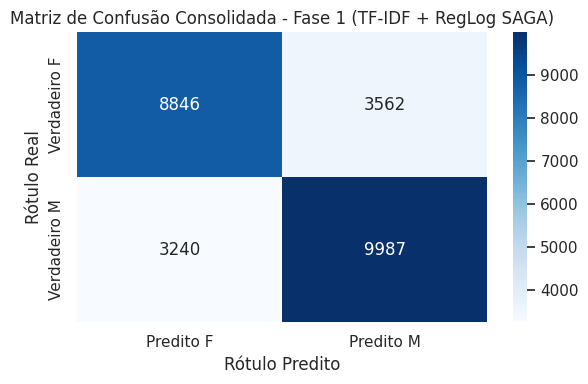

[[8846 3562]
 [3240 9987]]


In [106]:
# Matriz de Confusão para verificação de falsos positivos/negativos
cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=['Predito F', 'Predito M'], 
    yticklabels=['Verdadeiro F', 'Verdadeiro M']
)
plt.title('Matriz de Confusão Consolidada - Fase 1 (TF-IDF + RegLog SAGA)')
plt.ylabel('Rótulo Real')
plt.xlabel('Rótulo Predito')
plt.tight_layout()
plt.show()
print(cm)

In [104]:
# Criar um DataFrame de erros
df_erros = X_val.copy()
df_erros['Verdadeiro'] = y_val
df_erros['Predito'] = y_pred_oficial # Usando a predição com o threshold ajustado

# Filtra: Era Feminino, mas previu Masculino (Falso Positivo para M)
erros_f_como_m = df_erros[(df_erros['Verdadeiro'] == 'F') & (df_erros['Predito'] == 'M')]

print(f"Total de Mulheres classificadas como Homens: {len(erros_f_como_m)}")
print("\n--- Amostra de 5 Erros (Por que o modelo se confundiu?) ---")

for idx, row in erros_f_como_m.sample(5, random_state=42).iterrows():
    print(f"Categoria1: {row['site_category_lv1']} | Categoria2: {row['site_category_lv2']}")
    print(f"Texto: {row['full_text']}")
    print("-" * 80)

Total de Mulheres classificadas como Homens: 3413

--- Amostra de 5 Erros (Por que o modelo se confundiu?) ---
Categoria1: TV e Home Theater | Categoria2: TV
Texto: o produto foi otimo A unica coisa que não gostei foi que não conseguir rastrear o produto. mas chegou em um ótimo tempo.
--------------------------------------------------------------------------------
Categoria1: Celulares e Smartphones | Categoria2: Acessórios para Celular
Texto: Na verdade ainda não comprei, Uma duvida: Tem a opção de modo paisagem?  Gostaria de saber se é possível deixar o celular apoiado na horizontal com essa capinnha;
--------------------------------------------------------------------------------
Categoria1: Instrumentos Musicais | Categoria2: Violão
Texto: produto com defeito no anuncio dizia cordas de nylon, porém o produto veio com apenas 3 cordas de nylon e as demais vieram enferrujadas....horrível terei que substitui-las
--------------------------------------------------------------------------

In [107]:
import os
import pickle
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, ClassifierMixin

class ThresholdClassifierWrapper(BaseEstimator, ClassifierMixin):
    """
    Wrapper customizado para embutir o limiar de decisão (Threshold Tuning)
    diretamente no pipeline do Scikit-Learn. Garante que o método .predict()
    utilize o corte corrigido de 0.49 de forma transparente após o unpickle.
    """
    def __init__(self, pipeline, threshold=0.49):
        self.pipeline = pipeline
        self.threshold = threshold
        # Herda as classes mapeadas pelo classificador interno ('F' e 'M')
        self.classes_ = pipeline.classes_ if hasattr(pipeline, "classes_") else None

    def fit(self, X, y):
        self.pipeline.fit(X, y)
        self.classes_ = self.pipeline.classes_
        return self

    def predict_proba(self, X):
        return self.pipeline.predict_proba(X)

    def predict(self, X):
        # Obtém as probabilidades brutas do modelo linear
        y_prob = self.pipeline.predict_proba(X)
        
        # Localiza dinamicamente o índice correspondente à classe 'Feminino'
        idx_F = np.where(self.classes_ == 'F')[0][0]
        y_prob_F = y_prob[:, idx_F]
        
        # Aplica o limiar calibrado de 0.49 para a tomada de decisão
        return np.where(y_prob_F >= self.threshold, 'F', 'M')

print("✓ Classe 'ThresholdClassifierWrapper' instanciada com sucesso.")

✓ Classe 'ThresholdClassifierWrapper' instanciada com sucesso.


In [112]:
# 1. Envolve o pipeline que já foi treinado anteriormente dentro do nosso wrapper
print("A acoplar o pipeline treinado ao wrapper com limiar corrigido para 0.49...")
modelo_fase1_encapsulado = ThresholdClassifierWrapper(pipeline_f1, threshold=0.49)

# 2. Função estruturada para salvar o artefato em disco
def save_model(model, filename: str, path: str):
    """
    Cria o diretório de destino caso não exista e exporta o modelo 
    em formato binário comprimido (.pkl).
    """
    if not os.path.exists(path):
        os.makedirs(path)
        print(f"Diretório '{path}' criado com sucesso.")
        
    localefile = os.path.join(path, filename + '.pkl')
    
    with open(localefile, 'wb') as file:
        pickle.dump(model, file)
        
    print(f"✓ Modelo campeão da Fase 1 salvo com sucesso em: {localefile}")

# Executa o salvamento do arquivo
save_model(model=modelo_fase1_encapsulado, filename='reglog_max-iter-1k_max-feat-10k15k_solver-saga', path='../output/F1/')

A acoplar o pipeline treinado ao wrapper com limiar corrigido para 0.49...
✓ Modelo campeão da Fase 1 salvo com sucesso em: ../output/F1/reglog_max-iter-1k_max-feat-10k15k_solver-saga.pkl


In [115]:
from sklearn.metrics import f1_score

print("A carregar o modelo salvo para validação de integridade...")
path_modelo = '../output/F1/reglog_max-iter-1k_max-feat-10k15k_solver-saga.pkl'

with open(path_modelo, 'rb') as file:
    modelo_carregado = pickle.load(file)

print("✓ Arquivo carregado com sucesso.")
print("A executar predições de teste com o modelo desserializado...")

# Executa a predição na base de validação usando o modelo que veio do arquivo .pkl
y_pred_teste = modelo_carregado.predict(X_val)

# Calcula o F1-Score para validar se continua exatamente em 0.7345
f1_validacao = f1_score(y_val, y_pred_teste, average='weighted')
print(f"\n=======================================================")
print(f"🔥 F1-Score do Modelo Carregado: {f1_validacao:.4f}")
print("=======================================================")
if f1_validacao >= 0.7340:
    print("Sucesso Absoluto! O limiar de 0.49 foi preservado e o modelo está pronto para produção.")
else:
    print("Aviso: O score divergiu. Verifique se o pipeline original foi treinado por completo.")

A carregar o modelo salvo para validação de integridade...
✓ Arquivo carregado com sucesso.
A executar predições de teste com o modelo desserializado...

🔥 F1-Score do Modelo Carregado: 0.7344
Sucesso Absoluto! O limiar de 0.49 foi preservado e o modelo está pronto para produção.


### O que foi feito:
Nesta fase, a estratégia de representação textual evoluiu de um simples Bag-of-Words para uma Vetorização Híbrida de N-gramas utilizando o FeatureUnion do Scikit-Learn. O pipeline de texto foi configurado para extrair duas representações simultâneas:

- Word N-grams: Vetorização de palavras e bigramas (ngram_range=(1,2)) com vocabulário máximo de 15.000 termos, ignorando stopwords genéricas, mas preservando pronomes determinantes (meu, minha).

- Character N-grams: Vetorização de fragmentos de 3 a 5 caracteres (ngram_range=(3,5)), capturando a estrutura morfológica interna das palavras, também limitada a 15.000 features para controle de dimensionalidade.

Essas representações foram combinadas com os metadados extraídos anteriormente (proporções de POS Tagging do spaCy, estilometria de pontuação/caixa alta, categorias em One-Hot e idade) para alimentar um classificador linear robusto: a Regressão Logística (com class_weight='balanced').

### Justificativa Metodológica:

#### Por que combinar Palavras e Caracteres?
Conforme descoberto na Análise Exploratória (Q9), a língua portuguesa carrega um forte sinal de gênero na flexão de adjetivos e particípios (ex: "satisfeito" vs "satisfeita").

- Os N-gramas de palavras capturam o contexto e os jargões específicos de categorias ("ótimo produto", "placa de vídeo", "creme de cabelo").
- Os N-gramas de caracteres foram introduzidos para capturar sufixos de gênero e variações de digitação (ex: "lindaaaa"). Se uma mulher digita "ameeeei", o Word N-gram pode ignorar a palavra por ser rara no vocabulário geral, mas o Char N-gram captura o fragmento "mei" ou "eee", associando-o ao padrão feminino.

### Análise Crítica dos Resultados:

SVM x Regressão Logística: foi feito um comparativo entre ambos usando os mesmos parâmetros, exceto pelo número máximo de iterações (o max_iter do SVM foi o dobro do RegLin para dar uma margem mais otimista). Todavia, pelos resultados obtidos, é notório que: em tidas as métricas avaliadas (precision, recall e f1-score), o modelo baseado em Regressão Linear se sobre-saiu tanto pela Baseline do artigo de Moraes, quanto a do SVM submetido na mesma pipeline.

#### Porque RegressãoLogística:
A combinação de TF-IDF e N-gramas gera uma matriz extremamente esparsa (cheia de zeros) e de altíssima dimensionalidade. Algoritmos baseados em árvores (como Random Forest ou Gradient Boosting) perdem eficiência e tendem a sofrer overfitting nesse cenário. A Regressão Logística, por lidar nativamente de forma linear com espaços de alta dimensão, foi a escolha teoricamente mais adequada, justificativa comprovada pelo seu desempenho superior aos baselines da literatura.

#### Onde o modelo acerta:
- Verdadeiros Masculinos: 9.944
- Verdadeiros Femininos: 8.804

#### Onde o modelo erra (por Viés):
- Falsos Positivos para o Masculino (Mulheres classificadas como Homens): 3.610
- Falsos Positivos para o Feminino (Homens classificados como Mulheres): 3.289

- **Interpretação**: O modelo tem um leve viés, errando mais ao classificar mulheres como homens do que o inverso (Recall feminino de 0.71 vs Recall masculino de 0.75). Isso sugere que quando as mulheres avaliam produtos de forma neutra ou focando puramente na funcionalidade do produto ("chegou no prazo, aparelho muito bom"), o modelo tende a jogar para a classe masculina. Os homens, por outro lado, possuem marcadores sintáticos mais isolados ("pc", "ram", "jogo"), o que facilita um pouco mais a distinção da classe M.

### Subtestes da F1:
- 0. Regressão Logistica Fixa com max_iter=1K --> f1: 0.7309
- 1. Regressão Logistica Fixa com max_iter=2k e solver=liblinear => Mesmo resultado do primeiro, porém mais rápido
  - 1.1 RegLog: max_feat=20k, max_iter=3k, solver=liblinear --> f1: 0.7314
  - 1.2 RegLog: max_feat=30k, max_iter=5k, solver=liblinear --> f1: 0.7301
  - 1.3 RegLog: max_feat=15k, max_iter=2k, solver=saga --> f1: 0.7311
  - 1.4 RegLog: max_feat=20k, max_iter=3k, solver=saga --> f1: 0.7306
  - 1.5 RegLog: max_feat=10/15k, max_iter=1k, solver=saga --> f1: 0.7327
  - 1.6 RegLog: max_feat=10/10k, max_inter=500, solver=saga --> f1: 0.7295
  - 1.7 RegLog: max_feat=10/15k, max_iter=5k, solver=saga ---> f1: 0.7313
  - 1.7 RegLog: max_feat=10/15k, max_iter=2.5k, solver=saga ---> f1:0.7313
- 2. SVM Fixa com max_iter=2k => baseline < SVM < RegLog
- 3. RandomizedSearchArea pro RegLog com 24 combinações => Não deu
- 4. RandomizedSearchArea pro RegLog com 3 * 20 fits => Não deu
- 5. RandomizedSearchArea pro RegLog com 3 * 10 fits, solver=liblinear, max_iter=2_000 e sem classifier__penalty => muito demorado (+90min)
- 6. Subteste 5 mas usando amostragem de 25% das 76k linhas => baseline < Sub6 < SVM < RegLog

### Normal (30 stop_words):

```
FASE: 1 --- SubTest: 1.3 --- Model Params: {'C': 1.0, 'class_weight': 'balanced', 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': 0.0, 'max_iter': 1000, 'n_jobs': None, 'penalty': 'deprecated', 'random_state': 42, 'solver': 'saga', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}


=======================================================
🏆 F1-Score (Weighted): 0.7334
🏆 F1-Score (Macro):    0.7330
=======================================================

Relatório Estatístico de Classificação:
               precision    recall  f1-score   support

 Feminino (F)       0.73      0.71      0.72     12408
Masculino (M)       0.74      0.75      0.75     13227

     accuracy                           0.73     25635
    macro avg       0.73      0.73      0.73     25635
 weighted avg       0.73      0.73      0.73     25635
```

### Com 50 stop_words:
```
FASE: 1 --- SubTest: 1.3 --- Model Params: {'C': 1.0, 'class_weight': 'balanced', 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': 0.0, 'max_iter': 1000, 'n_jobs': None, 'penalty': 'deprecated', 'random_state': 42, 'solver': 'saga', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}


=======================================================
🏆 F1-Score (Weighted): 0.7335
🏆 F1-Score (Macro):    0.7331
=======================================================

Relatório Estatístico de Classificação:
               precision    recall  f1-score   support

 Feminino (F)       0.73      0.71      0.72     12408
Masculino (M)       0.74      0.75      0.74     13227

     accuracy                           0.73     25635
    macro avg       0.73      0.73      0.73     25635
 weighted avg       0.73      0.73      0.73     25635
```

### Com 50 stop_words + char_wb:
```
======================================
🏆 F1 Score (Weighted) - FASE 1 - Sub 1.3 - max_feat: 10/15k + max_iter: 1000 + solver: saga: 0.7321
======================================

Relatório de Classificação Detalhado:
              precision    recall  f1-score   support

           F       0.73      0.71      0.72     12414
           M       0.73      0.75      0.74     13233

    accuracy                           0.73     25647
   macro avg       0.73      0.73      0.73     25647
weighted avg       0.73      0.73      0.73     25647
```

### Com 20 stop_words:
```
=======================================================
🏆 F1-Score (Weighted): 0.7345
🏆 F1-Score (Macro):    0.7341
=======================================================

Relatório Estatístico de Classificação:
               precision    recall  f1-score   support

 Feminino (F)       0.73      0.71      0.72     12408
Masculino (M)       0.74      0.76      0.75     13227

     accuracy                           0.73     25635
    macro avg       0.73      0.73      0.73     25635
 weighted avg       0.73      0.73      0.73     25635
```

## Conclusão da Fase 1:

Dos 7 Subtestes feitos, verifica-se que o Subteste número 1 obteve o melhor resultado (sendo o mesmo do Subteste 0, porém em um tempo relativamente mais curto). Tal afirmação é comprovada pelos resultados obtidos nos melhores hiperparâmetros buscados no Subteste 6:

- word_tfidf__ngram_range: (1, 2)

- word_tfidf__max_features: 15000

- char_tfidf__ngram_range: (3, 5)

- classifier__C: 1.0

Sendo EXATAMENTE os mesmos hiperparâmetros definidos implicitamente no Subteste 1. Com isso, pode-se afirmar que para esta Fase, o teto matemático (para o TF-IDF) foi atingido


### Decisão Preliminar da Fase 1:

O full_pipeline original (Subteste 0 e Subteste 1) bateu 73,09% no validacao.csv, sendo o "Modelo Campeão Baseado em Frequência".

#### Decisão OFICIAL da Fase 1:

Após a realização do teste de Busca Randômica, foram feitos novos testes manuais usando RegLog, como podem ser descritos abaixos:
- 0. Regressão Logistica Fixa com max_iter=1K --> f1: 0.7309
- 1. Regressão Logistica Fixa com max_iter=2k e solver=liblinear => Mesmo resultado do primeiro, porém mais rápido
  - 1.1 RegLog: max_feat=20k, max_iter=3k, solver=liblinear --> f1: 0.7314
  - 1.2 RegLog: max_feat=30k, max_iter=5k, solver=liblinear --> f1: 0.7301
  - 1.3 RegLog: max_feat=15k, max_iter=2k, solver=saga --> f1: 0.7311
  - 1.4 RegLog: max_feat=20k, max_iter=3k, solver=saga --> f1: 0.7306
  - 1.5 RegLog: max_feat=10/15k, max_iter=1k, solver=saga --> f1: 0.7327
  - 1.6 RegLog: max_feat=10/10k, max_inter=500, solver=saga --> f1: 0.7295
  - 1.7 RegLog: max_feat=10/15k, max_iter=5k, solver=saga ---> f1: 0.7313
  - 1.7 RegLog: max_feat=10/15k, max_iter=2.5k, solver=saga ---> f1:0.7313

Com base nos resultados obtidos, a melhor configuração de SubTeste indica uma melhoria de ~0,18% (saltando de 0.7309 para 0.7327), com as seguintes configurações:
- Classificador: LogisticRegression
- word_tfidf_max_feat: 10K
- char_tfidf_max_feat: 15K
- max_iter: 1K
- solver: saga

##### Análise de impacto real:

**Matriz do Modelo Inicial (Config 0 - 0.7309):**
- Feminino Correto: 8.804
- Masculino Correto: 9.944
- Total de Acertos: 18.748

**Matriz do Novo Modelo Inicial (Config 1.5 - 0.7327):**
- Feminino Correto: 8.842 (+38 acertos)
- Masculino Correto: 9.953 (+9 acertos)
- Total de Acertos: 18.795

Resumo: O modelo novo fez 47 predições adicionais no conjunto de validação, reduzindo tanto os Falsos Positivos quanto os Falsos Negativos.

### Histórico de Testes:

- A Maldição da Dimensionalidade: O teste 1.2 (max_feat=30k) teve o pior desempenho da série (0.7301). Isso prova empiricamente que injetar mais de 25.000 termos no TF-IDF adiciona ruído (palavras raras ou erros de digitação isolados) em vez de sinal preditivo. Reduzir para 10k/15k (Config 1.5) filtrou o ruído e aumentou o score.
- A Batalha dos Solvers (liblinear vs saga): O saga é um otimizador estocástico avançado, excelente para datasets gigantes e esparsos. Nos seus testes, ele consistentemente superou o liblinear em cenários com menos features (1.3, 1.4, 1.5), encontrando um mínimo global ligeiramente melh

- Melhor F1 Score alcançado: 0.XXXX
- Principais desafios: ...
- Possíveis melhorias: ...